In [1]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
archivo = "StreamingHistory_Extended.csv"
spotify : pd.DataFrame = pd.read_csv(archivo)
spotify

C:\Users\50030868\AppData\Local\Temp\ipykernel_11980\4060803231.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  spotify : pd.DataFrame = pd.read_csv(archivo)


,ts,username,platform,ms_played,conn_country,user_agent_decrypted,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,is_podcast
0,2020-12-06T02:51:11Z,11145402699,"iOS 14.2 (iPhone12,3)",145610,AR,unknown,Hey Jude - Remastered 2015,The Beatles,1,spotify:track:0aym2LBJBk9DAYuHHutrIl,NaN,NaN,NaN,trackdone,fwdbtn,True,NaN,False,1607222710755,False
1,2020-12-06T02:53:31Z,11145402699,"iOS 14.2 (iPhone12,3)",138692,AR,unknown,Hacer un puente,La Franela,Hacer Un Puente,spotify:track:18Q3WTfyWX1tdS1cp42NhA,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223071185,False
2,2020-12-06T02:53:53Z,11145402699,"iOS 14.2 (iPhone12,3)",22662,AR,unknown,Happy Together - Remastered,The Turtles,All the Singles,spotify:track:2admbUc576sC6M0QeUkg2C,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223210387,False
3,2020-12-06T02:53:56Z,11145402699,"iOS 14.2 (iPhone12,3)",2716,AR,unknown,Demons,Imagine Dragons,Night Visions,spotify:track:5qaEfEh1AtSdrdrByCP7qR,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223233165,False
4,2020-12-06T02:53:57Z,11145402699,"iOS 14.2 (iPhone12,3)",116,AR,unknown,"Paint It, Black",The Rolling Stones,Aftermath,spotify:track:63T7DJ1AFDD6Bn8VzG6JE8,NaN,NaN,NaN,fwdbtn,fwdbtn,True,NaN,False,1607223236453,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125344,2018-10-05T22:44:53Z,11145402699,"iOS 12.0 (iPhone8,1)",1365,AR,unknown,Gente Que No Sabe Lo Que Quiere,Litto Nebbia,Solo Se Trata de Vivir / Solopiano Vol. 1,spotify:track:3u8sP95YHOsYwRQfms6kgc,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779491211,False
125345,2018-10-05T22:44:54Z,11145402699,"iOS 12.0 (iPhone8,1)",1344,AR,unknown,11 Y 6,Fito Paez,Giros,spotify:track:2PkTjm1QAJCZbJ9MqC4RqA,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779492740,False
125346,2018-10-05T22:44:55Z,11145402699,"iOS 12.0 (iPhone8,1)",832,AR,unknown,Mientes,Charly García,Tango 4,spotify:track:670dXRMKr9vVtGk01dYeSr,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779494205,False
125347,2018-10-05T22:44:56Z,11145402699,"iOS 12.0 (iPhone8,1)",1194,AR,unknown,Apostar al Amor,Los Tipitos,Push,spotify:track:6PyBNCpOX5uOjKDNjNNgjq,NaN,NaN,NaN,fwdbtn,fwdbtn,False,NaN,False,1538779495059,False


In [4]:
spotify.columns

Index(['ts', 'username', 'platform', 'ms_played', 'conn_country',
       'user_agent_decrypted', 'master_metadata_track_name',
       'master_metadata_album_artist_name', 'master_metadata_album_album_name',
       'spotify_track_uri', 'episode_name', 'episode_show_name',
       'spotify_episode_uri', 'reason_start', 'reason_end', 'shuffle',
       'skipped', 'offline', 'offline_timestamp', 'is_podcast'],
      dtype='object')

In [5]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125349 entries, 0 to 125348
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   ts                                 125349 non-null  object
 1   username                           125349 non-null  int64 
 2   platform                           125349 non-null  object
 3   ms_played                          125349 non-null  int64 
 4   conn_country                       125349 non-null  object
 5   user_agent_decrypted               104897 non-null  object
 6   master_metadata_track_name         123953 non-null  object
 7   master_metadata_album_artist_name  123953 non-null  object
 8   master_metadata_album_album_name   123953 non-null  object
 9   spotify_track_uri                  123953 non-null  object
 10  episode_name                       168 non-null     object
 11  episode_show_name                  168 non-null     

In [6]:
spotify["ts"] = pd.to_datetime(spotify["ts"])

print("Primera reproducción:", spotify["ts"].min())
print("Última reproducción:", spotify["ts"].max())

Primera reproducción: 2014-06-27 18:01:15+00:00
Última reproducción: 2024-05-23 23:56:20+00:00


In [7]:
canciones = spotify[spotify["is_podcast"] == False]

cant_canciones = canciones["master_metadata_track_name"].nunique()

print("Canciones diferentes:", cant_canciones)

Canciones diferentes: 9708


In [8]:
max_reproducion_canciones = canciones["ms_played"].sum()

max_reproducion_canciones_minuto = max_reproducion_canciones  / 1000 / 60

print("Maximo de  tiempo reporducido por minuto", max_reproducion_canciones_minuto)


Maximo de  tiempo reporducido por minuto 207998.65765


In [9]:
artistas = canciones.groupby("master_metadata_album_artist_name"
)["ms_played"].sum()

artista_mas_escuchado = artistas.idxmax()

print("Artista más escuchado:", artista_mas_escuchado)


Artista más escuchado: Charly García


In [11]:
canciones_mas = canciones.groupby("master_metadata_track_name")["ms_played"].sum()

cancion_mas_escuchada = canciones_mas.idxmax()

print("cancion mas escuchada: ", cancion_mas_escuchada)

cancion mas escuchada:  Rain


In [14]:
Charly = canciones[canciones["master_metadata_album_artist_name"] == artista_mas_escuchado]

tema_de_charly = Charly.groupby("master_metadata_track_name")["ms_played"].sum().idxmax()

print("Canción más escuchada de", artista_mas_escuchado, ":", tema_de_charly)



Canción más escuchada de Charly García : Hablando a Tu Corazón


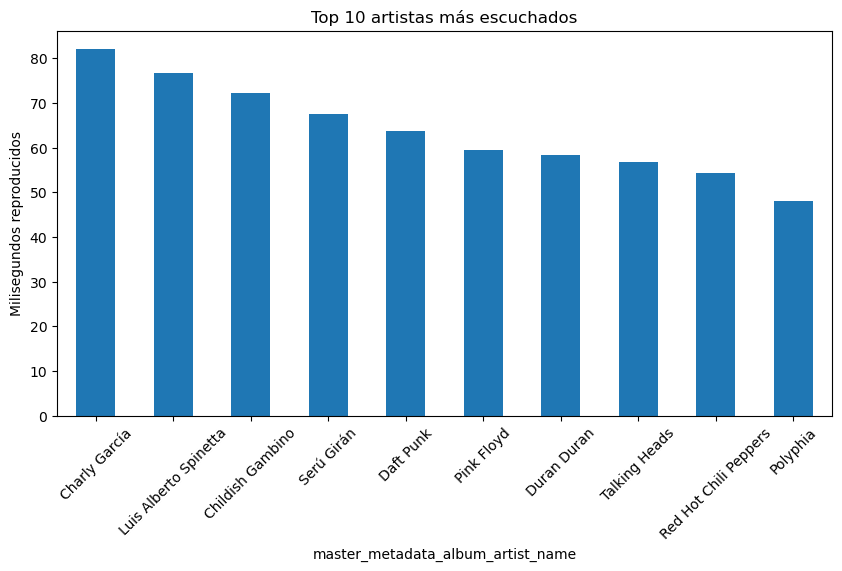

In [ ]:
top10_artistas = canciones.groupby("master_metadata_album_artist_name")["ms_played"].sum().sort_values(ascending=False).head(10)

top10_artistas = top10_artistas / (1000 * 60 * 60)


plt.figure(figsize=(10, 5))
top10_artistas.plot(kind="bar")
plt.title("Top 10 artistas más escuchados")
plt.ylabel("horas reproducidas")
plt.xticks(rotation=45)
plt.show()


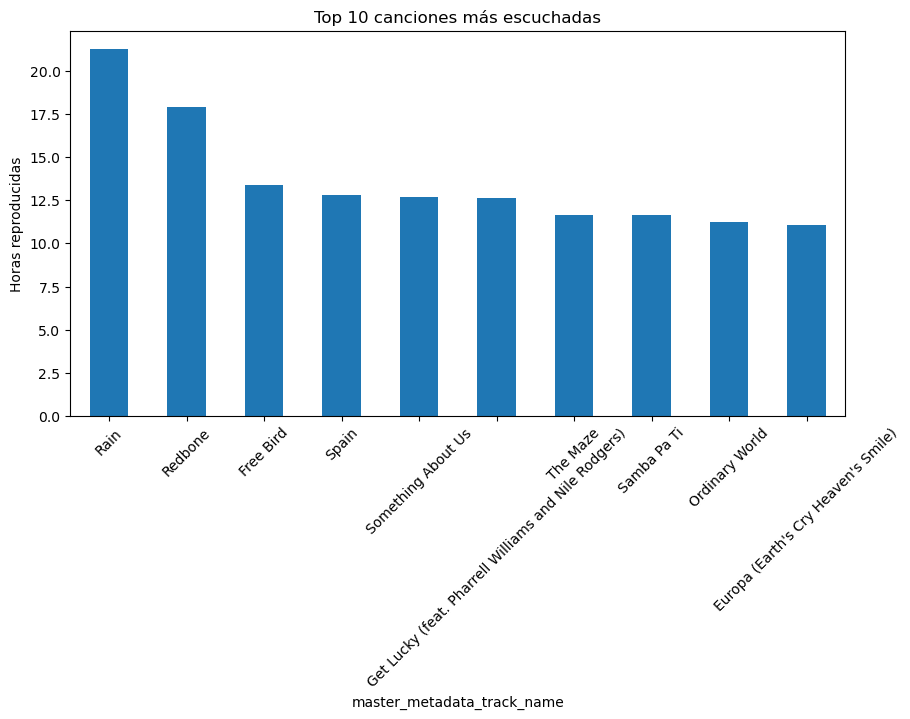

In [29]:
top10_canciones = canciones.groupby("master_metadata_track_name")["ms_played"].sum().sort_values(ascending=False).head(10)

top10_canciones = top10_canciones / (1000 * 60 * 60)

plt.figure(figsize=(10, 5))
top10_canciones.plot(kind="bar")
plt.title("Top 10 canciones más escuchadas")
plt.ylabel("Horas reproducidas")
plt.xticks(rotation=45)
plt.show()

C:\Users\50030868\AppData\Local\Temp\ipykernel_11980\138773224.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  canciones["dia_semana"] = canciones["ts"].dt.day_name()


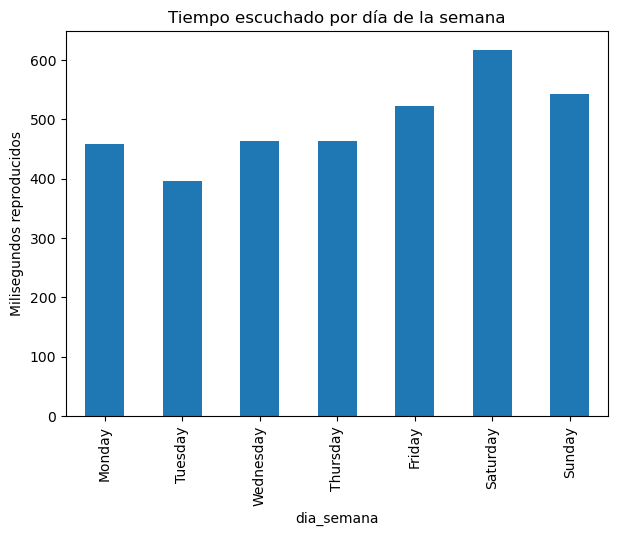

In [35]:
canciones["dia_semana"] = canciones["ts"].dt.day_name()

dias = canciones.groupby("dia_semana")["ms_played"].sum()

orden = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

dias = dias.reindex(orden)

dias = dias / (1000 * 60 * 60)

plt.figure(figsize=(7,5))
dias.plot(kind="bar")

plt.title("Tiempo escuchado por día de la semana")
plt.ylabel("Milisegundos reproducidos")
plt.show()

C:\Users\50030868\AppData\Local\Temp\ipykernel_11980\1852060265.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  canciones["hora"] = canciones["ts"].dt.hour


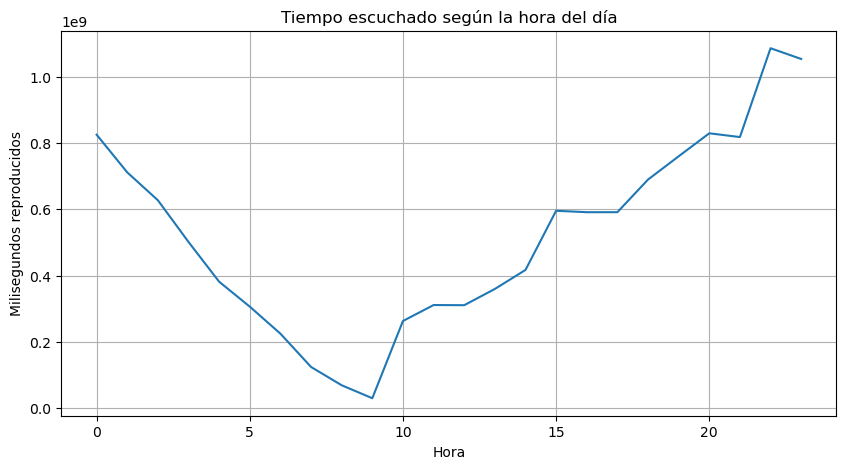

In [40]:
canciones["hora"] = canciones["ts"].dt.hour

horas = canciones.groupby("hora")["ms_played"].sum()

plt.figure(figsize=(10,5))
horas.plot(kind="line")

plt.title("Tiempo escuchado según la hora del día")
plt.xlabel("Hora")
plt.ylabel("Milisegundos reproducidos")

plt.grid()
plt.show()